# Acquisition check: saved series and manifest

Checks the recordings of the acquisition test (thesis Section 5.3.5, objective O1) made with
iCorrVision Grabber: **integrity** of the saved series, **frame count**, **intervals between
frames** per camera and, in two-camera mode, the **software pairing offset**.

**Input.** One row per recording in `acquisition_runs.csv` (next to this notebook), with the
columns:

| column | meaning |
|---|---|
| `folder` | folder holding the TIFFs and the manifest CSV of one recording |
| `backend` | `vimba` or `opencv` |
| `source` | description of the source, e.g. `Vimba X simulator G1-030` |
| `nominal_fps` | frame rate the camera or poll timer was set to |
| `frames_requested` | *optional*: frames the run was meant to record; if empty, the expected count is `nominal_fps × duration` from the manifest |
| `tag` | *optional*: short label appended to the figure name, to keep runs with the same backend and rate apart |

Set the environment variable `ACQ_RUNS` to use a different runs table, and `ACQ_OUT` for a
different output folder (default `results/` next to this notebook).

The recordings and the runs table are not distributed: `.gitignore` excludes image series and
CSV files, since recordings may show people or the laboratory. The outputs saved in this
notebook are those of the thesis runs.

**What the times mean.** The elapsed times in the manifest are software timestamps, taken when
each frame reaches the application's main (interface) thread, not when the sensor exposed it.
The jitter of the intervals therefore includes the load of the interface as well as the source.
The times are stored to four decimal places of a second, so intervals are resolved to 0.1 ms.

In [1]:
import os
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUNS_FILE = Path(os.environ.get("ACQ_RUNS", "acquisition_runs.csv"))
OUT_DIR = Path(os.environ.get("ACQ_OUT", "results"))
LATE_FACTOR = 1.5  # an interval above 1.5 × nominal counts as late (or a dropped frame)

OUT_DIR.mkdir(parents=True, exist_ok=True)
runs = pd.read_csv(RUNS_FILE)
runs

,folder,backend,source,nominal_fps,frames_requested,tag
0,recordings/protocol_speckle/vimba_10fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,10,500,NaN
1,recordings/protocol_speckle/vimba_30fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,30,500,NaN
2,recordings/protocol_speckle/vimba_60fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,60,500,NaN
3,recordings/protocol_speckle/vimba_2cam_10fps,vimba,2 Vimba X simulators 1024x768 Mono8 speckle,10,300,NaN
4,recordings/protocol_speckle/opencv_10fps,opencv,v4l2loopback FFmpeg 1280x1024 speckle (greyscale),10,500,NaN
5,recordings/protocol_speckle/opencv_30fps,opencv,v4l2loopback FFmpeg 1280x1024 speckle (greyscale),30,500,NaN
6,recordings/protocol/vimba_10fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,10,500,pattern
7,recordings/protocol/vimba_30fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,30,500,pattern
8,recordings/protocol/vimba_60fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,60,500,pattern
9,recordings/protocol/vimba_2cam_10fps,vimba,Vimba X simulators 656x520 + 1024x768 test pat...,10,300,pattern


## Reading one recording

The manifest is the single `*.csv` in the recording folder (the grabber names it
`<prefix>.csv`). Its format, as written by the grabber: delimiter `;`; column `date`; then per
camera `<label>_frame_time` (seconds since recording started) and `<label>_frame_name`, with
label `left` for camera 0 and `right` for camera 1. Images are named
`<prefix>_<camera index>_<4-digit number>.tiff`.

In [2]:
LABELS = {0: "left", 1: "right"}


def load_manifest(folder: Path) -> pd.DataFrame:
    """Read the manifest of one recording; there must be exactly one CSV in the folder."""
    csvs = sorted(folder.glob("*.csv"))
    if len(csvs) != 1:
        raise ValueError(f"{folder}: expected one manifest CSV, found {[c.name for c in csvs]}")
    return pd.read_csv(csvs[0], sep=";", dtype={"date": str})


def cameras_in(manifest: pd.DataFrame) -> list[int]:
    """Camera indices present in the manifest, from its <label>_frame_time columns."""
    return [i for i, label in LABELS.items() if f"{label}_frame_time" in manifest.columns]

## Integrity

Per camera: files listed in the manifest but missing on disk, listed files that fail to open,
and TIFFs on disk that the manifest does not list.

In [3]:
def integrity(folder: Path, manifest: pd.DataFrame, index: int) -> dict:
    """Compare the files listed for camera `index` with the TIFFs of that camera on disk."""
    label = LABELS[index]
    listed = manifest[f"{label}_frame_name"].astype(str).tolist()
    on_disk = {p.name for p in folder.glob(f"*_{index}_*.tiff")}
    missing = [n for n in listed if n not in on_disk]
    unreadable = [n for n in listed if n in on_disk and cv.imread(str(folder / n), cv.IMREAD_UNCHANGED) is None]
    first = next((n for n in listed if n in on_disk and n not in unreadable), None)
    shape = cv.imread(str(folder / first), cv.IMREAD_UNCHANGED).shape if first else None
    return {
        "listed": len(listed),
        "on_disk": len(on_disk),
        "missing": missing,
        "unreadable": unreadable,
        "not_in_manifest": sorted(on_disk - set(listed)),
        "duplicates_in_manifest": len(listed) - len(set(listed)),
        "resolution": f"{shape[1]}x{shape[0]}" if shape else "",
    }

## Intervals

Per camera, from the manifest's elapsed times: mean, standard deviation, minimum and maximum
interval, the achieved frame rate (1 / mean interval) and the intervals above
`LATE_FACTOR` × nominal interval, with their positions (frame index at the end of the late
interval, counting from 0).

In [4]:
def intervals_ms(manifest: pd.DataFrame, index: int) -> np.ndarray:
    """Intervals between consecutive manifest rows of camera `index`, in milliseconds."""
    times = manifest[f"{LABELS[index]}_frame_time"].to_numpy(dtype=float)
    return np.diff(times) * 1000.0


def interval_stats(iv: np.ndarray, nominal_fps: float) -> dict:
    """Summary of the intervals `iv` (ms) against the nominal rate, including late intervals."""
    nominal_ms = 1000.0 / nominal_fps
    late = np.flatnonzero(iv > LATE_FACTOR * nominal_ms)
    return {
        "mean_ms": iv.mean(),
        "std_ms": iv.std(ddof=1) if iv.size > 1 else np.nan,
        "min_ms": iv.min(),
        "max_ms": iv.max(),
        "achieved_fps": 1000.0 / iv.mean(),
        "late_count": late.size,
        "late_positions": (late + 1).tolist(),
    }


def pairing_offset_ms(manifest: pd.DataFrame) -> np.ndarray:
    """Per row, left elapsed time minus right elapsed time (two-camera runs only)."""
    return (manifest["left_frame_time"] - manifest["right_frame_time"]).to_numpy() * 1000.0

## Figure per run

For each camera: a histogram of the intervals with the nominal interval marked, and the
interval against the frame index, where a stall of the source or of the interface appears as a
spike. The writer runs on its own thread, so its delays do not appear here.
Saved as `acquisition_<backend>_<fps>fps.pdf`, with `_2cam` appended for two-camera runs and
`_<tag>` if the run has a tag.

In [5]:
def run_figure(run: pd.Series, manifest: pd.DataFrame, cams: list[int]) -> Path:
    nominal_ms = 1000.0 / run.nominal_fps
    fig, axes = plt.subplots(len(cams), 2, figsize=(10, 3.2 * len(cams)), squeeze=False)
    for row, index in enumerate(cams):
        iv = intervals_ms(manifest, index)
        ax_hist, ax_seq = axes[row]
        ax_hist.hist(iv, bins=40, color="0.5")
        ax_hist.axvline(nominal_ms, color="tab:red", linestyle="--", label=f"nominal {nominal_ms:.1f} ms")
        ax_hist.set_xlabel("interval (ms)")
        ax_hist.set_ylabel("count")
        ax_hist.set_title(f"camera {index} ({LABELS[index]})")
        ax_hist.legend()
        ax_seq.plot(np.arange(1, iv.size + 1), iv, color="0.3", linewidth=0.8)
        ax_seq.axhline(nominal_ms, color="tab:red", linestyle="--")
        ax_seq.axhline(LATE_FACTOR * nominal_ms, color="tab:orange", linestyle=":", label=f"{LATE_FACTOR} × nominal")
        ax_seq.set_xlabel("frame index")
        ax_seq.set_ylabel("interval (ms)")
        ax_seq.legend()
    fig.suptitle(f"{run.backend}, {run.source}, nominal {run.nominal_fps:g} fps")
    fig.tight_layout()
    suffix = "_2cam" if len(cams) == 2 else ""
    if "tag" in run and pd.notna(run.tag):
        suffix += f"_{run.tag}"
    path = OUT_DIR / f"acquisition_{run.backend}_{run.nominal_fps:g}fps{suffix}.pdf"
    fig.savefig(path)
    plt.show()
    return path

## All runs

Prints the details per run (including late-frame positions and file names that failed a
check), draws the figures, and builds the summary table.


=== recordings/protocol_speckle/vimba_10fps: vimba, Vimba X simulator 1024x768 Mono8 speckle, nominal 10 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.16, min 99.00, max 101.00; achieved 10.00 fps; late 0 at []


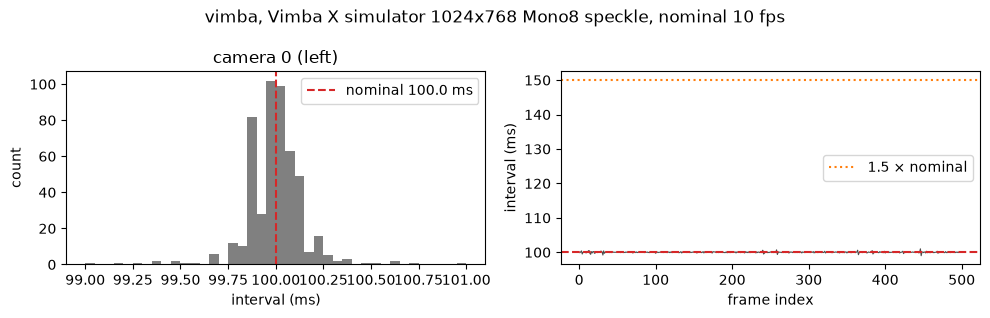

  figure: results/acquisition_vimba_10fps.pdf

=== recordings/protocol_speckle/vimba_30fps: vimba, Vimba X simulator 1024x768 Mono8 speckle, nominal 30 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 33.33 ms, sd 0.19, min 31.90, max 34.60; achieved 30.00 fps; late 0 at []


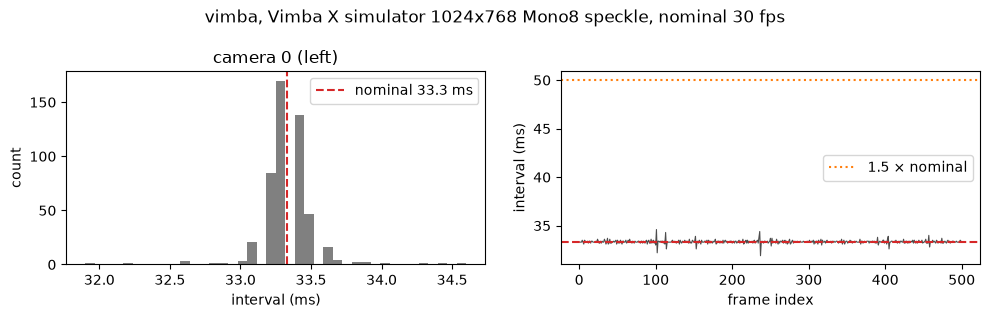

  figure: results/acquisition_vimba_30fps.pdf

=== recordings/protocol_speckle/vimba_60fps: vimba, Vimba X simulator 1024x768 Mono8 speckle, nominal 60 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 16.67 ms, sd 0.36, min 14.90, max 18.30; achieved 60.00 fps; late 0 at []


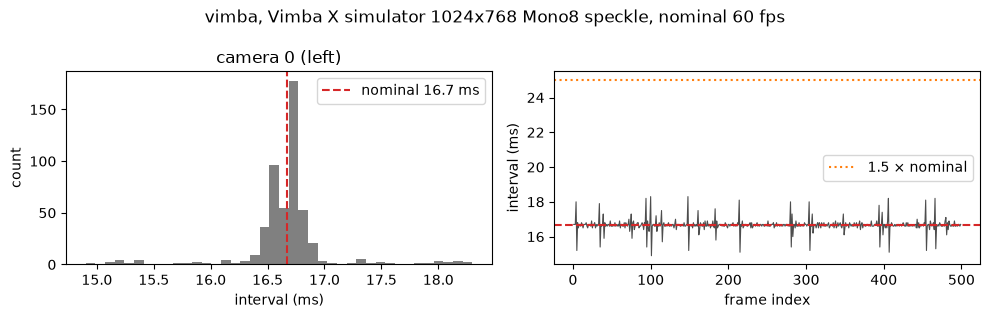

  figure: results/acquisition_vimba_60fps.pdf

=== recordings/protocol_speckle/vimba_2cam_10fps: vimba, 2 Vimba X simulators 1024x768 Mono8 speckle, nominal 10 fps, cameras [0, 1]


  camera 0: 300 rows, 300 TIFFs, expected 300 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.23, min 98.90, max 101.10; achieved 10.00 fps; late 0 at []


  camera 1: 300 rows, 300 TIFFs, expected 300 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.14, min 99.00, max 100.90; achieved 10.00 fps; late 0 at []
  pairing offset (left - right): mean -20.52 ms, sd 0.19, max |offset| 21.50 ms


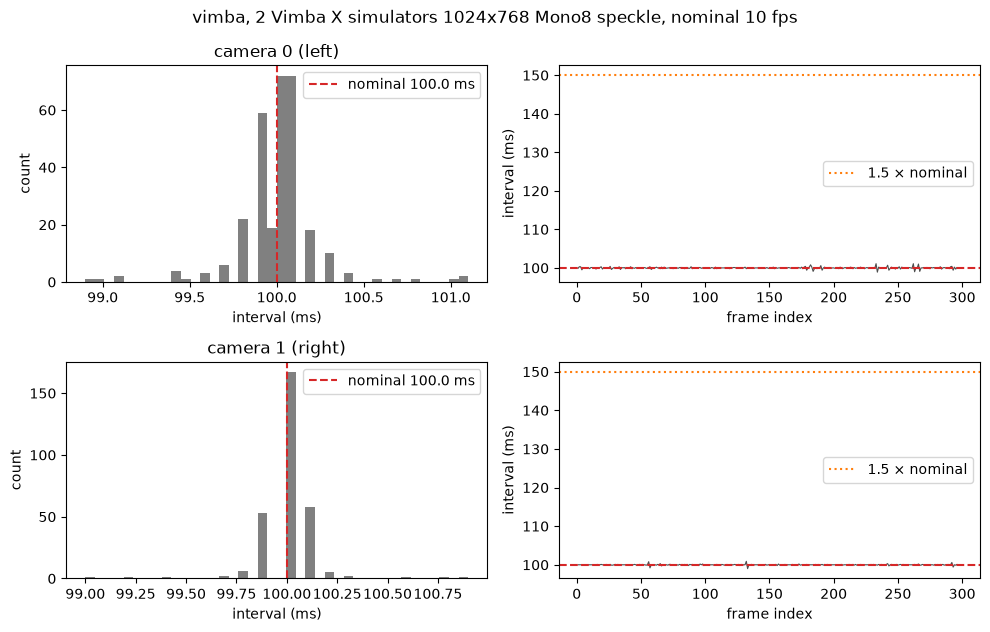

  figure: results/acquisition_vimba_10fps_2cam.pdf

=== recordings/protocol_speckle/opencv_10fps: opencv, v4l2loopback FFmpeg 1280x1024 speckle (greyscale), nominal 10 fps, cameras [0]


  camera 0: 500 rows, 501 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 1, duplicate rows 0
    not_in_manifest: ['run_0_0500.tiff']
    intervals: mean 100.00 ms, sd 0.28, min 98.60, max 101.50; achieved 10.00 fps; late 0 at []


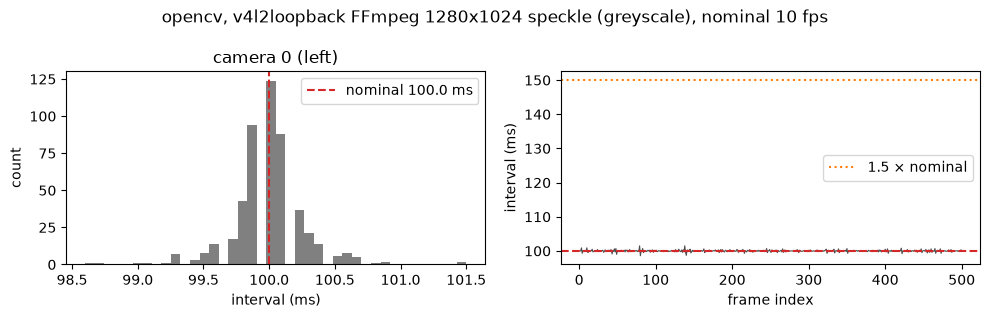

  figure: results/acquisition_opencv_10fps.pdf

=== recordings/protocol_speckle/opencv_30fps: opencv, v4l2loopback FFmpeg 1280x1024 speckle (greyscale), nominal 30 fps, cameras [0]


  camera 0: 500 rows, 514 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 14, duplicate rows 0
    not_in_manifest: ['run_0_0500.tiff', 'run_0_0501.tiff', 'run_0_0502.tiff', 'run_0_0503.tiff', 'run_0_0504.tiff', 'run_0_0505.tiff', 'run_0_0506.tiff', 'run_0_0507.tiff', 'run_0_0508.tiff', 'run_0_0509.tiff'] …
    intervals: mean 33.33 ms, sd 0.79, min 31.00, max 35.80; achieved 30.00 fps; late 0 at []


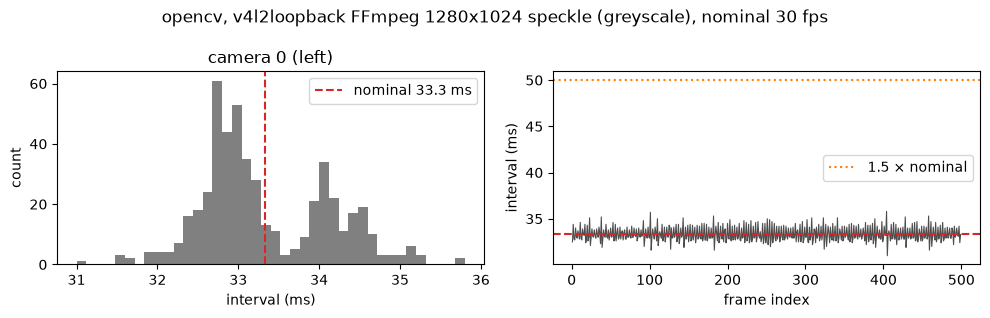

  figure: results/acquisition_opencv_30fps.pdf

=== recordings/protocol/vimba_10fps: vimba, Vimba X simulator 1024x768 Mono8 test pattern, nominal 10 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.16, min 99.20, max 100.90; achieved 10.00 fps; late 0 at []


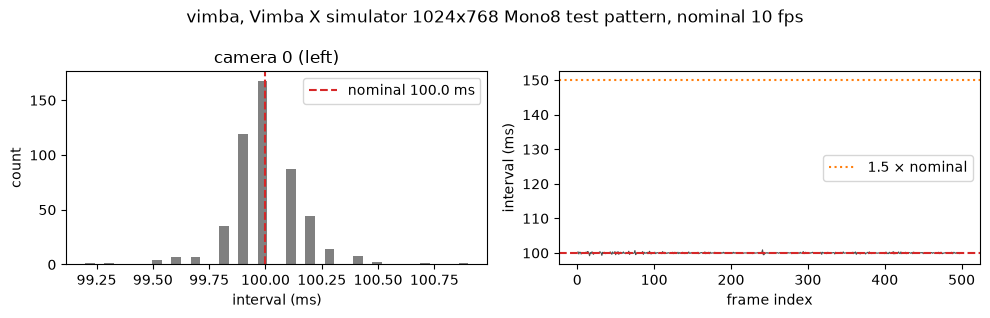

  figure: results/acquisition_vimba_10fps_pattern.pdf

=== recordings/protocol/vimba_30fps: vimba, Vimba X simulator 1024x768 Mono8 test pattern, nominal 30 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 33.33 ms, sd 0.16, min 32.30, max 34.60; achieved 30.00 fps; late 0 at []


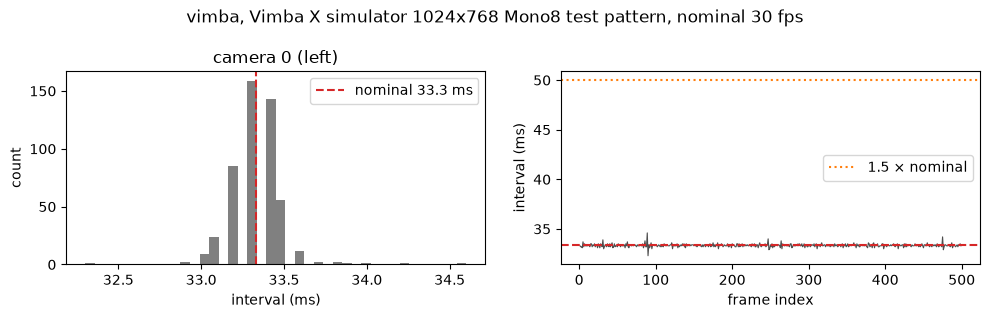

  figure: results/acquisition_vimba_30fps_pattern.pdf

=== recordings/protocol/vimba_60fps: vimba, Vimba X simulator 1024x768 Mono8 test pattern, nominal 60 fps, cameras [0]


  camera 0: 500 rows, 500 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 16.67 ms, sd 0.14, min 15.60, max 17.70; achieved 60.00 fps; late 0 at []


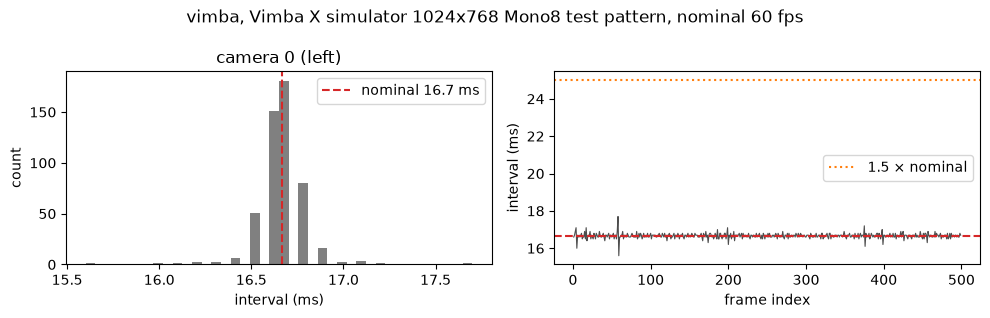

  figure: results/acquisition_vimba_60fps_pattern.pdf

=== recordings/protocol/vimba_2cam_10fps: vimba, Vimba X simulators 656x520 + 1024x768 test pattern, nominal 10 fps, cameras [0, 1]


  camera 0: 300 rows, 300 TIFFs, expected 300 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.11, min 99.30, max 100.80; achieved 10.00 fps; late 0 at []


  camera 1: 300 rows, 300 TIFFs, expected 300 (requested); missing 0, unreadable 0, not in manifest 0, duplicate rows 0
    intervals: mean 100.00 ms, sd 0.19, min 99.00, max 101.10; achieved 10.00 fps; late 0 at []
  pairing offset (left - right): mean -11.02 ms, sd 0.18, max |offset| 12.40 ms


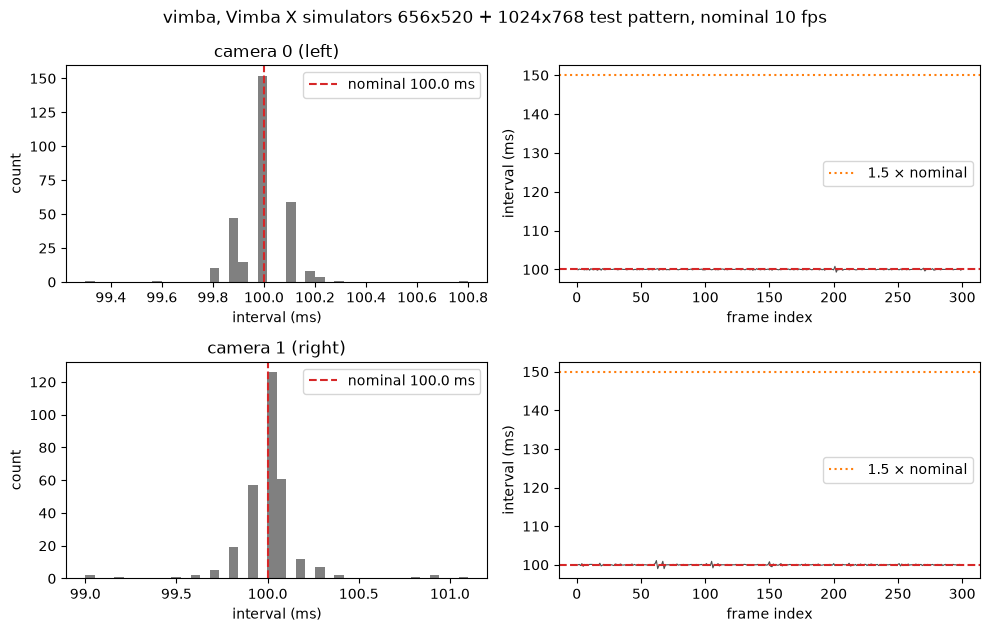

  figure: results/acquisition_vimba_10fps_2cam_pattern.pdf

=== recordings/protocol/opencv_10fps: opencv, v4l2loopback FFmpeg testsrc 1280x1024 (greyscale), nominal 10 fps, cameras [0]


  camera 0: 500 rows, 501 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 1, duplicate rows 0
    not_in_manifest: ['run_0_0500.tiff']
    intervals: mean 100.00 ms, sd 0.32, min 98.30, max 101.40; achieved 10.00 fps; late 0 at []


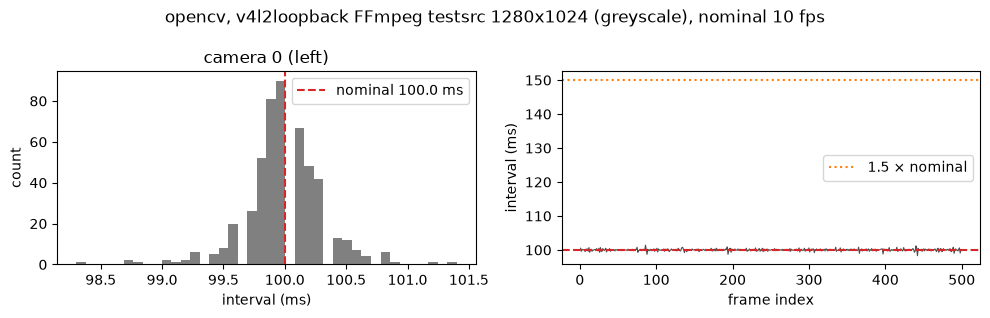

  figure: results/acquisition_opencv_10fps_pattern.pdf

=== recordings/protocol/opencv_30fps: opencv, v4l2loopback FFmpeg testsrc 1280x1024 (greyscale), nominal 30 fps, cameras [0]


  camera 0: 500 rows, 516 TIFFs, expected 500 (requested); missing 0, unreadable 0, not in manifest 16, duplicate rows 0
    not_in_manifest: ['run_0_0500.tiff', 'run_0_0501.tiff', 'run_0_0502.tiff', 'run_0_0503.tiff', 'run_0_0504.tiff', 'run_0_0505.tiff', 'run_0_0506.tiff', 'run_0_0507.tiff', 'run_0_0508.tiff', 'run_0_0509.tiff'] …
    intervals: mean 33.33 ms, sd 0.38, min 29.60, max 36.80; achieved 30.00 fps; late 0 at []


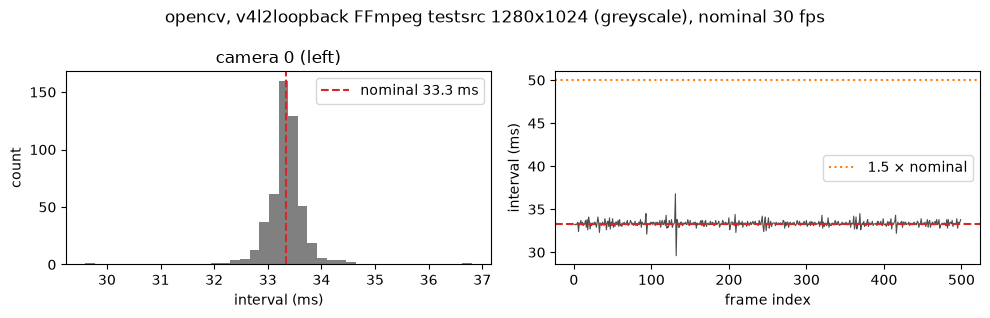

  figure: results/acquisition_opencv_30fps_pattern.pdf


In [6]:
rows = []
for _, run in runs.iterrows():
    folder = Path(run.folder)
    manifest = load_manifest(folder)
    cams = cameras_in(manifest)
    print(f"\n=== {run.folder}: {run.backend}, {run.source}, nominal {run.nominal_fps:g} fps, cameras {cams}")
    for index in cams:
        integ = integrity(folder, manifest, index)
        stats = interval_stats(intervals_ms(manifest, index), run.nominal_fps)
        times = manifest[f"{LABELS[index]}_frame_time"].to_numpy(dtype=float)
        duration = times[-1] - times[0]
        if pd.notna(run.get("frames_requested")):
            expected, basis = int(run.frames_requested), "requested"
        else:
            expected, basis = int(round(run.nominal_fps * duration)) + 1, "nominal fps × duration"
        print(f"  camera {index}: {integ['listed']} rows, {integ['on_disk']} TIFFs, "
              f"expected {expected} ({basis}); missing {len(integ['missing'])}, "
              f"unreadable {len(integ['unreadable'])}, not in manifest {len(integ['not_in_manifest'])}, "
              f"duplicate rows {integ['duplicates_in_manifest']}")
        for key in ("missing", "unreadable", "not_in_manifest"):
            if integ[key]:
                print(f"    {key}: {integ[key][:10]}{' …' if len(integ[key]) > 10 else ''}")
        print(f"    intervals: mean {stats['mean_ms']:.2f} ms, sd {stats['std_ms']:.2f}, "
              f"min {stats['min_ms']:.2f}, max {stats['max_ms']:.2f}; achieved {stats['achieved_fps']:.2f} fps; "
              f"late {stats['late_count']} at {stats['late_positions'][:20]}")
        rows.append({
            "run": str(run.folder),
            "backend": run.backend,
            "source": run.source,
            "camera": index,
            "resolution": integ["resolution"],
            "nominal_fps": run.nominal_fps,
            "frames_requested": expected,
            "expected_basis": basis,
            "frames_saved": integ["listed"] - len(integ["missing"]),
            "missing_or_unreadable": len(integ["missing"]) + len(integ["unreadable"]),
            "not_in_manifest": len(integ["not_in_manifest"]),
            "mean_interval_ms": stats["mean_ms"],
            "std_interval_ms": stats["std_ms"],
            "max_interval_ms": stats["max_ms"],
            "late_count": stats["late_count"],
            "achieved_fps": stats["achieved_fps"],
        })
    if len(cams) == 2:
        off = pairing_offset_ms(manifest)
        print(f"  pairing offset (left - right): mean {off.mean():.2f} ms, sd {off.std(ddof=1):.2f}, "
              f"max |offset| {np.abs(off).max():.2f} ms")
        for r in rows[-2:]:
            r.update(pair_offset_mean_ms=off.mean(), pair_offset_std_ms=off.std(ddof=1),
                     pair_offset_max_abs_ms=np.abs(off).max())
    print(f"  figure: {run_figure(run, manifest, cams)}")

## Summary

One row per camera per run; exported to `acquisition_summary.csv` in the output folder.

In [7]:
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "acquisition_summary.csv", index=False)
summary.round(2)

,run,backend,source,camera,resolution,nominal_fps,frames_requested,expected_basis,frames_saved,missing_or_unreadable,not_in_manifest,mean_interval_ms,std_interval_ms,max_interval_ms,late_count,achieved_fps,pair_offset_mean_ms,pair_offset_std_ms,pair_offset_max_abs_ms
0,recordings/protocol_speckle/vimba_10fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,0,1024x768,10,500,requested,500,0,0,100.00,0.16,101.0,0,10.0,NaN,NaN,NaN
1,recordings/protocol_speckle/vimba_30fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,0,1024x768,30,500,requested,500,0,0,33.33,0.19,34.6,0,30.0,NaN,NaN,NaN
2,recordings/protocol_speckle/vimba_60fps,vimba,Vimba X simulator 1024x768 Mono8 speckle,0,1024x768,60,500,requested,500,0,0,16.67,0.36,18.3,0,60.0,NaN,NaN,NaN
3,recordings/protocol_speckle/vimba_2cam_10fps,vimba,2 Vimba X simulators 1024x768 Mono8 speckle,0,1024x768,10,300,requested,300,0,0,100.00,0.23,101.1,0,10.0,-20.52,0.19,21.5
4,recordings/protocol_speckle/vimba_2cam_10fps,vimba,2 Vimba X simulators 1024x768 Mono8 speckle,1,1024x768,10,300,requested,300,0,0,100.00,0.14,100.9,0,10.0,-20.52,0.19,21.5
5,recordings/protocol_speckle/opencv_10fps,opencv,v4l2loopback FFmpeg 1280x1024 speckle (greyscale),0,1280x1024,10,500,requested,500,0,1,100.00,0.28,101.5,0,10.0,NaN,NaN,NaN
6,recordings/protocol_speckle/opencv_30fps,opencv,v4l2loopback FFmpeg 1280x1024 speckle (greyscale),0,1280x1024,30,500,requested,500,0,14,33.33,0.79,35.8,0,30.0,NaN,NaN,NaN
7,recordings/protocol/vimba_10fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,0,1024x768,10,500,requested,500,0,0,100.00,0.16,100.9,0,10.0,NaN,NaN,NaN
8,recordings/protocol/vimba_30fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,0,1024x768,30,500,requested,500,0,0,33.33,0.16,34.6,0,30.0,NaN,NaN,NaN
9,recordings/protocol/vimba_60fps,vimba,Vimba X simulator 1024x768 Mono8 test pattern,0,1024x768,60,500,requested,500,0,0,16.67,0.14,17.7,0,60.0,NaN,NaN,NaN


## Reading the result

- **Integrity.** A listed file that is missing or unreadable, or a name listed twice, means the
  series does not match its manifest. `frames_saved` counts the listed rows whose file exists; it
  does not subtract names listed twice, so it is valid only when the duplicate count is 0, as it
  is in every thesis run.
- **Files not in the manifest.** With the OpenCV backend, images saved after the last row are
  expected: Record and Stop take effect late when poll requests queue up, and frames still in
  transit when Stop is pressed receive no row. They are not part of the recorded series.
- **Intervals.** The check finds late frames among the listed ones. It cannot detect frames
  missing from the manifest altogether, and it does not compare image content. It establishes
  that the listed series is complete and regular, not that Record and Stop delimited the
  intended interval.